In [1]:
import pandas as pd
import numpy as np
import xarray as xr
from tqdm import tqdm
from XRO import XRO
from RCENSO import *
rpy.verbosity(0)
import warnings
warnings.filterwarnings("ignore")
%config InlineBackend.figure_format = 'retina'

In [2]:
nmembers = 1

In [3]:
ds = xr.open_dataset('data\oras5_indices_1958-2025.nc',engine='netcdf4').sel(time=slice('1958-01', '2024-12'))
ds = standardize_time_to_month_start(ds)
ds = ds[['Nino34', 'WWV'] + [v for v in ds.data_vars if v not in ('Nino34', 'WWV')]]
TS = ds.to_array().values.T
tl = 42*12
TS_TP_anual = pack_TS_anualTP(TS,order=2)
t = np.arange(len(ds.time))

In [4]:
hypers=[
    {
        'units':20000,
        'lr':1,
        'sr':1,
        'rc_connectivity':0.0,
        'input_connectivity':0.10,
        'input_scaling':1.0,
        'ridge':5e-6,
        'noise_rc':0.05,
        'noise_in':0,
        'seed': None,
        'use_raw_input':True,
        'ip_reservoir':True,
    },
    {
        'units':[20000,12000],
        'lr':[1,1],
        'sr':[1,1],
        'rc_connectivity':[0,0],
        'input_connectivity':[0.1,0.1],
        'input_scaling':[1.0,1.0],
        'ridge':5e-6,
        'noise_rc':[0.05,0],
        'noise_in':[0,0],
        'seed': None,
        'deep':True,
        'deep_ip_list':[True,False]
    },
]

In [5]:
ds = xr.open_dataset('data\oras5_indices_1958-2025.nc',engine='netcdf4').sel(time=slice('1958-01', '2024-12'))
ds = standardize_time_to_month_start(ds)
ds = ds[['Nino34', 'WWV'] + [v for v in ds.data_vars if v not in ('Nino34', 'WWV')]]
TS = ds.to_array().values.T
tl = 42*12
TS_TP_anual = pack_TS_anualTP(TS,order=2)
t = np.arange(len(ds.time))

In [6]:
# 维度增加实验
results, results_mean = dimension_addition_ensemble_forecast(
    ds, tl=tl, hypers=hypers, 
    retain_var=['Nino34', 'WWV'],
    nmembers=nmembers, steps=22
)

Configuration: 2 hyperparameter sets × 1 members = 2 total members

Dimension Addition Ensemble Forecast - Baseline: Nino34+WWV
Testing: Nino34+WWV + ['NPMM', 'SPMM', 'IOB', 'TNA', 'ATL3', 'IOD', 'SIOD', 'SASD']

Running baseline (Nino34+WWV)...


Training ensemble members:   0%|          | 0/1 [00:00<?, ?it/s]

Layer 1: units=20000, sr=1, lr=1, ip_reservoir=True
Layer 2: units=12000, sr=1, lr=1, ip_reservoir=False


Forecasting with ensemble: 100%|██████████| 2/2 [02:01<00:00, 60.94s/it]


✓ Baseline completed (dim=2, members=2)

Testing 8 combinations...


...

Training ensemble members: 100%|██████████| 1/1 [00:27<00:00, 27.51s/it]


Layer 1: units=20000, sr=1, lr=1, ip_reservoir=True
Layer 2: units=12000, sr=1, lr=1, ip_reservoir=False


Training ensemble members: 100%|██████████| 1/1 [00:27<00:00, 27.38s/it]


Layer 1: units=20000, sr=1, lr=1, ip_reservoir=True
Layer 2: units=12000, sr=1, lr=1, ip_reservoir=False


Testing combinations: 100%|██████████| 8/8 [36:10<00:00, 271.34s/it]


In [7]:
Ytest = TS[tl:]
R, rmse = calculate_ensemble_skill(
    results, Ytest, wl=12, showdim=0, ismv3=True
)

In [10]:
# 初始化XRO模型
xro_model = XRO(ncycle=12, ac_order=2, is_forward=True)
# ========== 运行 XRO 实验 ==========
xro_results = dimension_addition_xro_forecast(
    ds=ds,
    tl=slice('1958-01','1999-12'),
    xro_model=xro_model,
    maskb=['Nino34', 'IOD'],
    n_month=19
)
R_xro = {}
rmse_xro = {}
for mode in xro_results.keys():
    R_xro[mode],rmse_xro[mode] = ndforecast_skill(xro_results[mode],Ytest,wl=12,plot=False)



XRO Model - Baseline: Nino34+WWV
Testing: Nino34+WWV + ['NPMM', 'SPMM', 'IOB', 'TNA', 'ATL3', 'IOD', 'SIOD', 'SASD']

Running baseline (Nino34+WWV)...
✓ Baseline completed (dim=2)

Testing 8 combinations...


Testing combinations: 100%|██████████| 8/8 [00:20<00:00,  2.53s/it]


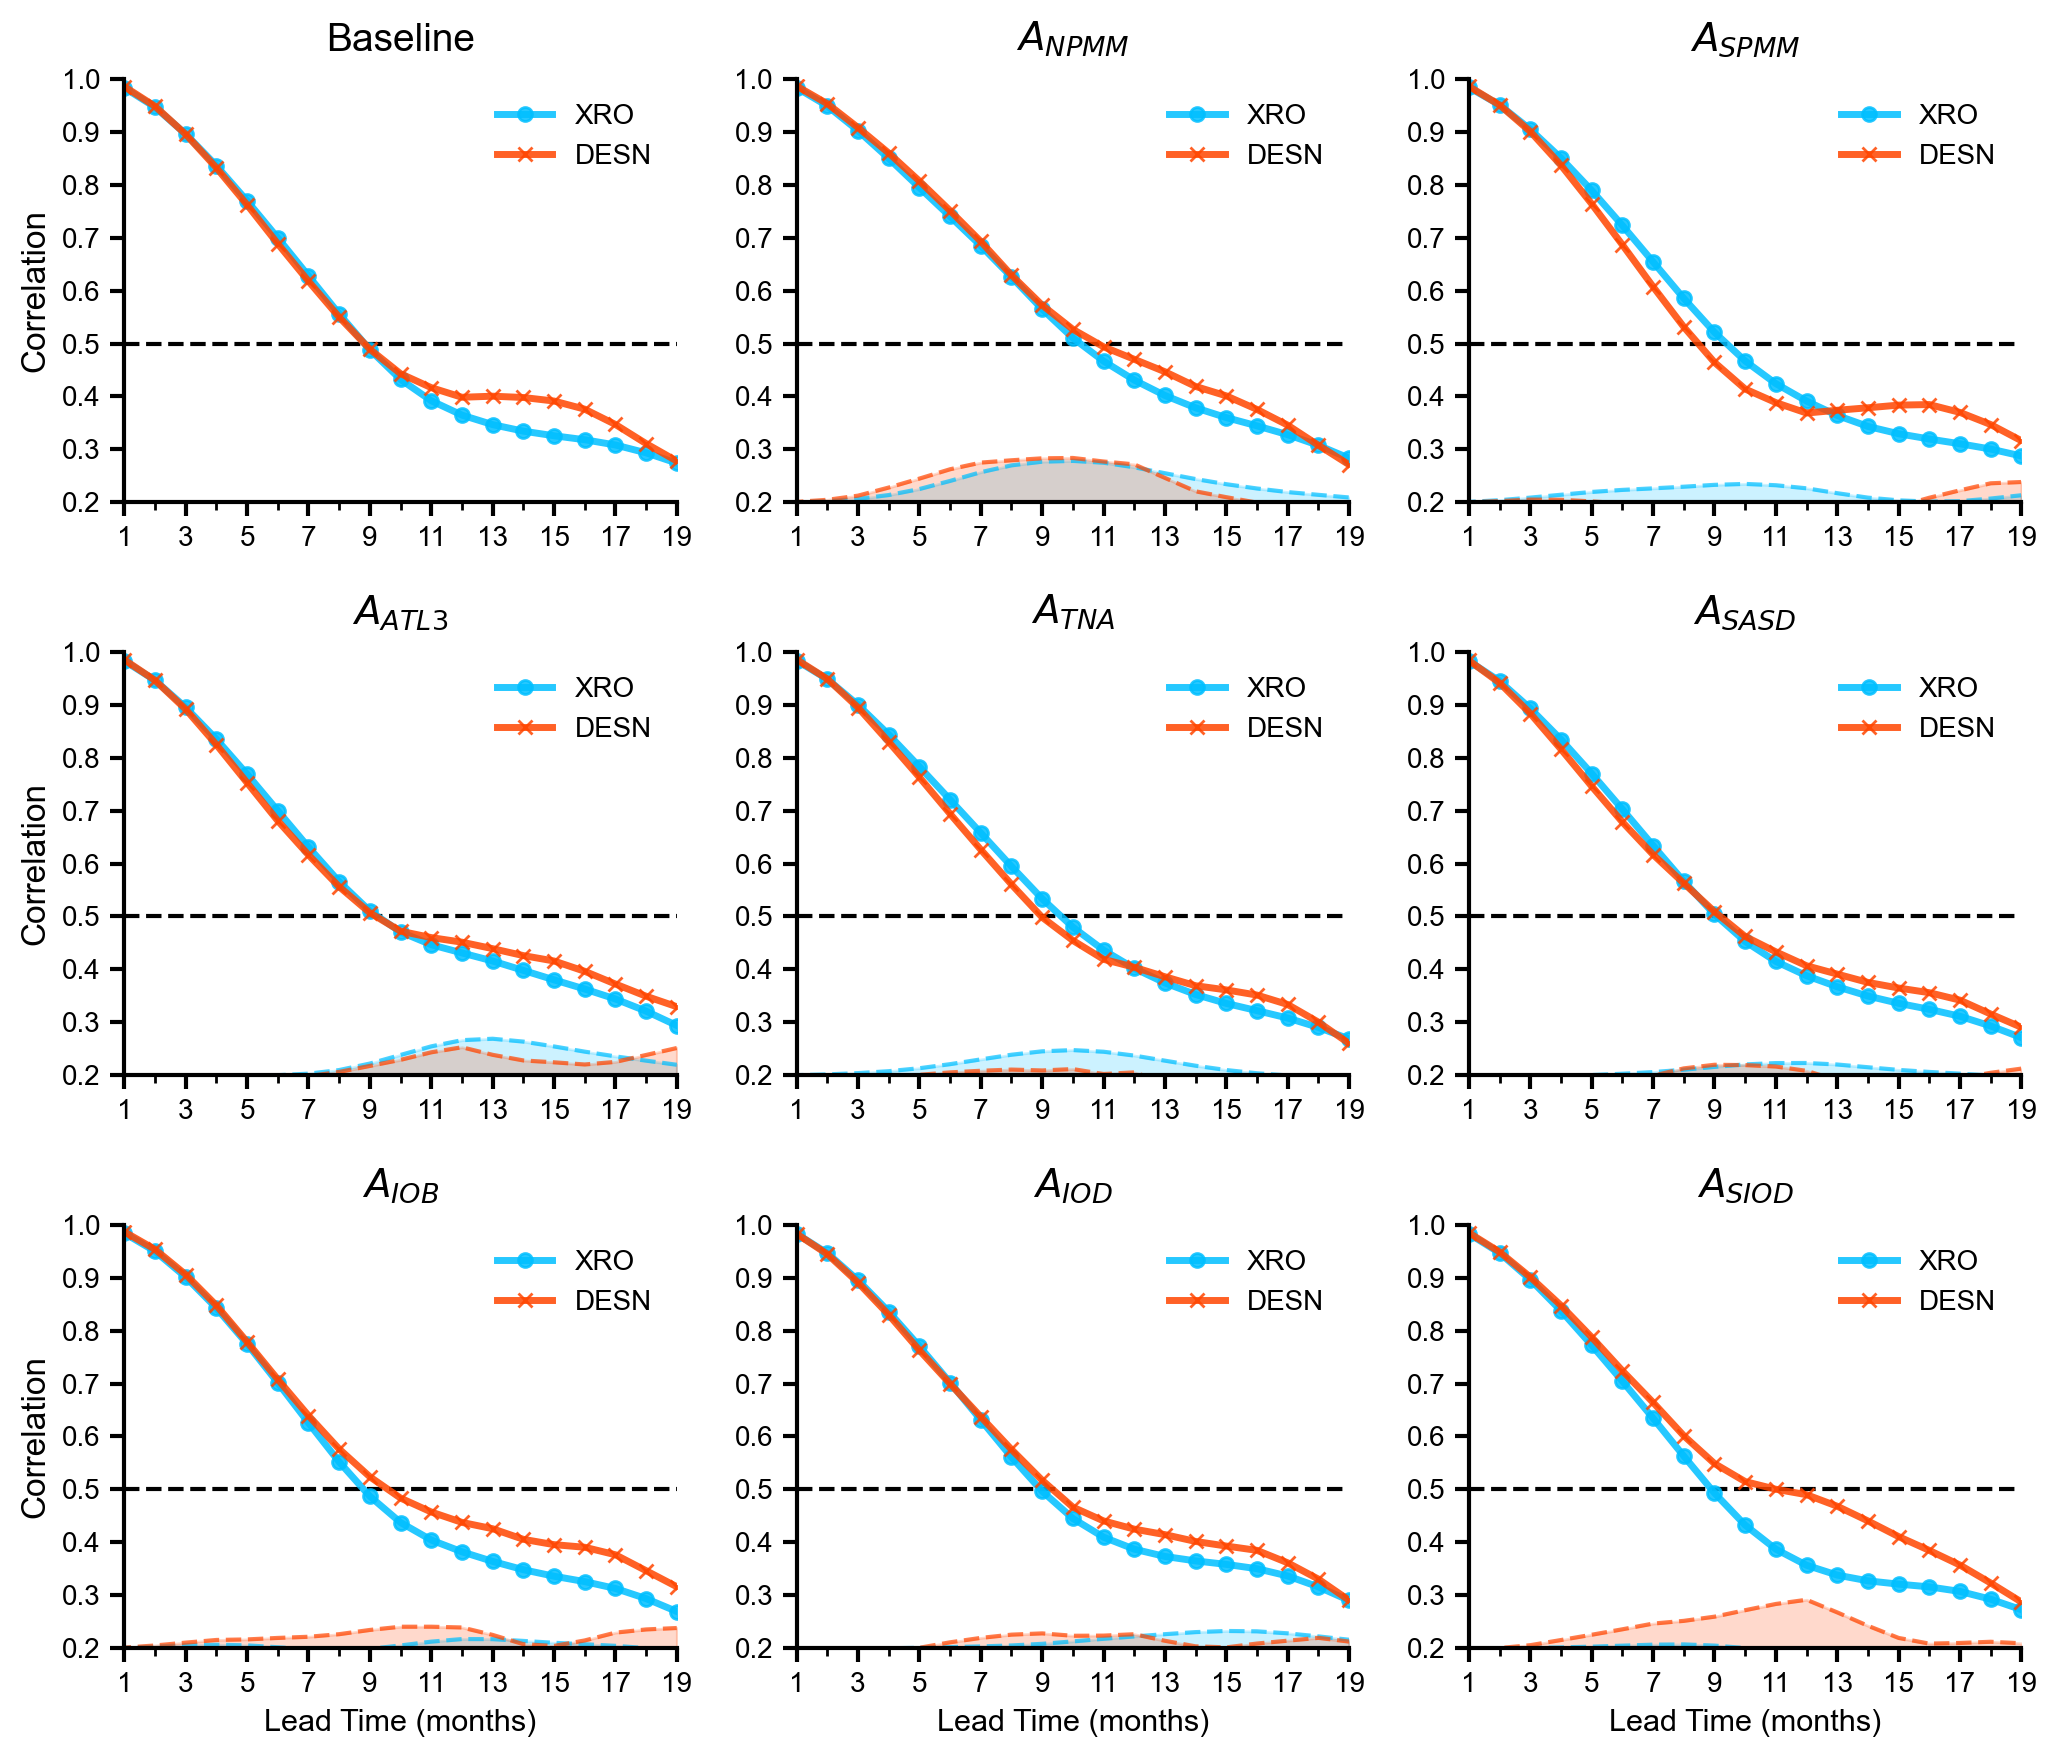

In [20]:
keys = ['baseline','NPMM','SPMM','ATL3','TNA','SASD','IOB','IOD','SIOD']
R_xro = reorder_and_rename_results(R_xro, key_order=keys)
R = reorder_and_rename_results(R, key_order=keys)
comprison_skill={'XRO':R_xro,'DESN':R}
fig = visualize_skill_comparison_vs_baseline(comprison_skill,ref_line=0.5,show_difference=True,
                                             diff_reverse=True,
                                             subtitle_template='$A_{{{mode}}}$')
